In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from abm.rewards import *
from abm.rewards import _cholesky_grid, dog_rbf_landscape, _min_max, sinusoid_landscape
from abm.utils import plot_reward_grids, plot_reward_grid, rbf

## 1. Sample GPs from various prior kernels

### 1.a RBF kernel

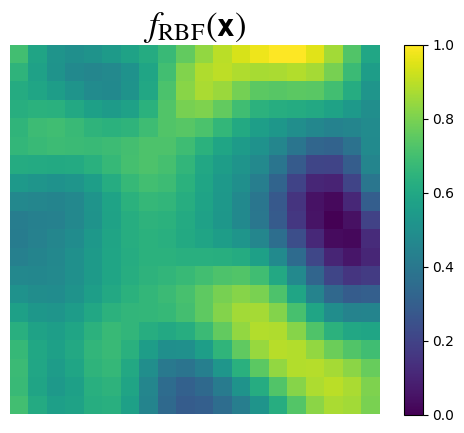

In [18]:
rng = np.random.default_rng(42)
n_children   = 1
grid_size    = 20
length_scale = 3
target_correlation = 0.99

# create correlation matrix
R = np.full((n_children+1,n_children+1), target_correlation)
np.fill_diagonal(R, 1.0)

parent, children = make_parent_and_children_cholesky(
    rng=rng,
    grid_size=grid_size,
    n_children=n_children,
    length_scale=length_scale,
    corr_matrix=R
)

plt.rcParams['mathtext.fontset'] = 'stix'

plt.imshow(parent, cmap='viridis', origin='lower')
plt.colorbar()
plt.axis('off')
plt.title(r'$f_\text{RBF}(\mathbf{\mathsf{x}})$', 
          fontsize=25,
        )
plt.show()

### 1.b Gabor

In [52]:
def gabor_covariance(
    grid_size: int   = 20,
    theta: float     = 0.0,
    frequency: float = 1/3,
    sigma: float     = 3.0,
    amplitude: float = 1.0,
    jitter: float    = 1e-8
):
    rows, cols = np.mgrid[:grid_size, :grid_size]
    points = np.column_stack((rows.ravel(), cols.ravel()))
    differences = points[:, None, :] - points[None, :, :]

    squared_distances = np.sum(differences**2, axis=-1)
    direction = np.array([np.sin(theta), np.cos(theta)])
    projected_distances = differences @ direction
    covariance = amplitude**2 * np.exp(
        -squared_distances / (2 * sigma**2)
    ) * np.cos(2 * np.pi * frequency * projected_distances)
    covariance.flat[:: covariance.shape[0] + 1] += jitter

    return covariance

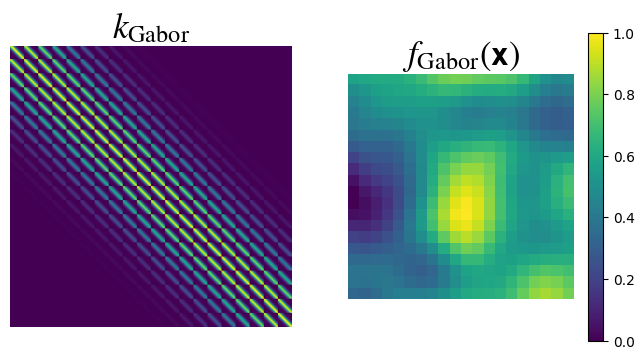

In [58]:
rng = np.random.default_rng(42)
n_children   = 1
grid_size    = 20
length_scale = 3
w            = 0
sigma        = length_scale #(length_scale**(-2)-w**2)**0.5

parent, children = make_gabor_set(
    rng=rng,
    grid_size=grid_size,
    n_children=n_children,
    frequency=w, #1/(length_scale**2),
    sigma=length_scale,
    theta=0.0,
    amplitude=1.0,
)
k_gabor = gabor_covariance(
    frequency = w,
    sigma = sigma,
)

plt.rcParams['mathtext.fontset'] = 'stix'

fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].imshow(k_gabor)
ax[0].axis('off')
ax[0].set_title(r'$k_\text{Gabor}$', 
          fontsize=25,
        )

im1 = ax[1].imshow(parent, cmap='viridis', origin='lower')
fig.colorbar(im1, ax=ax[1])  
ax[1].axis('off')
ax[1].set_title(r'$f_\text{Gabor}(\mathbf{\mathsf{x}})$', 
          fontsize=25,
        )
plt.show()

### 1.c Difference of Gaussians (DoG)

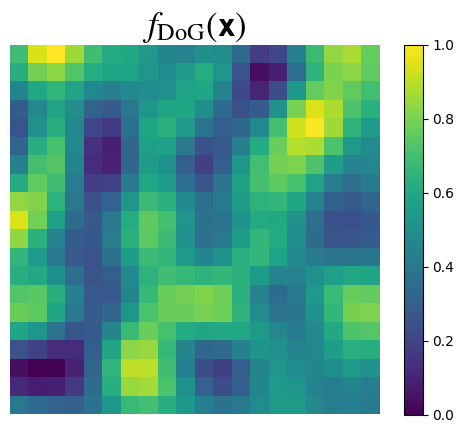

In [30]:
rng = np.random.default_rng(42)
n_children   = 1
grid_size    = 20
length_scale = 3

parent, children = make_DoG_set(
    rng=rng,
    grid_size=grid_size,
    n_children=n_children,
    sigma_outer=length_scale,
    sigma_inner=length_scale/2,
    amplitude=1.0,
)

plt.rcParams['mathtext.fontset'] = 'stix'

plt.imshow(parent, cmap='viridis', origin='lower')
plt.colorbar()
plt.axis('off')
plt.title(r'$f_\text{DoG}(\mathbf{\mathsf{x}})$', 
          fontsize=25,
        )
plt.show()

## 3. Difference of Gaussians (DoG)
We generate a parent DoG landscape, and correlated children by jitetering parameters

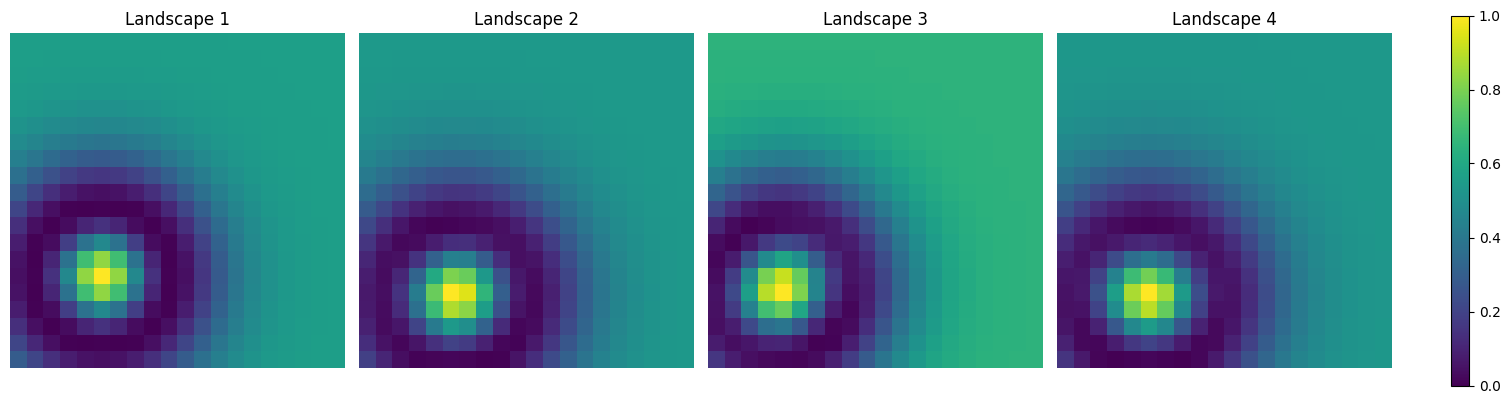

Correlations: [np.float64(0.9), np.float64(0.9000000000000002), np.float64(0.9000000000000002)]


In [43]:
rng = np.random.default_rng(42)
n_children = 3
grid_size = 20

parent, children = make_parent_and_children_mexican_hat(
    rng=rng,
    grid_size=grid_size,
    n_children=n_children,
    # frequency=3,
    sigma_inner=2,
    sigma_outer=4,
    correlation=0.9,
    center=(grid_size//4, grid_size//4)
)

plot_reward_grids(np.array([parent] + children))
print('Correlations:', check_correlations(parent, children, target_correlation=0.9, tol=0.1)[1])

## 4. Correlated DoG
We generate a base spatially-correlated landscape and superimpose a DoG kernel

In [3]:
rng = np.random.default_rng(24)
grid_size = 11
length_scale= 1.5
sigma_outer= 1.5
sigma_inner= 0.75

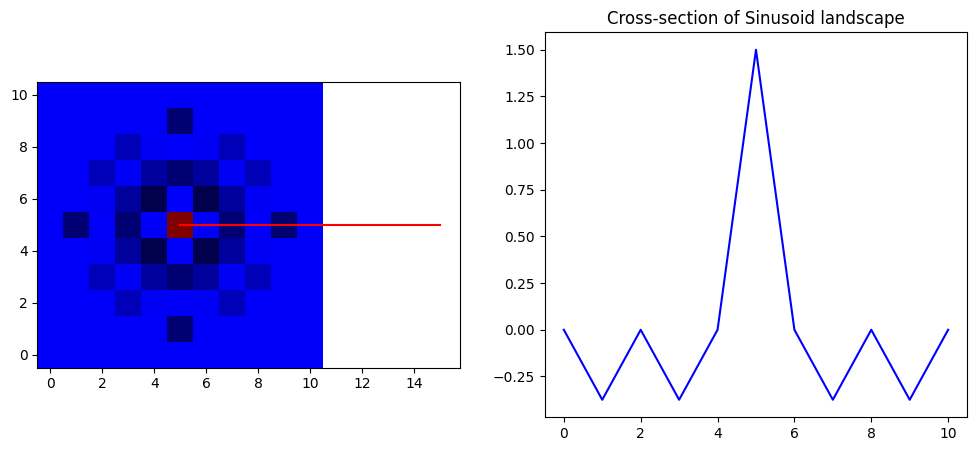

In [4]:
sin_reward = sinusoid_landscape(grid_size=grid_size, center=(grid_size//2, grid_size//2), sigma_inner=sigma_inner*2, sigma_outer=sigma_outer*2)
# dog_rbf = _min_max(dog_rbf)

# Make left and right subplots, heatmap on left and line plot on right
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  
ax1.imshow(sin_reward, origin='lower', cmap='seismic')
ax1.plot([grid_size//2,grid_size//2+10],[grid_size//2,grid_size//2], color='red')
ax2.plot(sin_reward[grid_size//2, :], color='blue')
ax2.set_title('Cross-section of Sinusoid landscape')
plt.show()

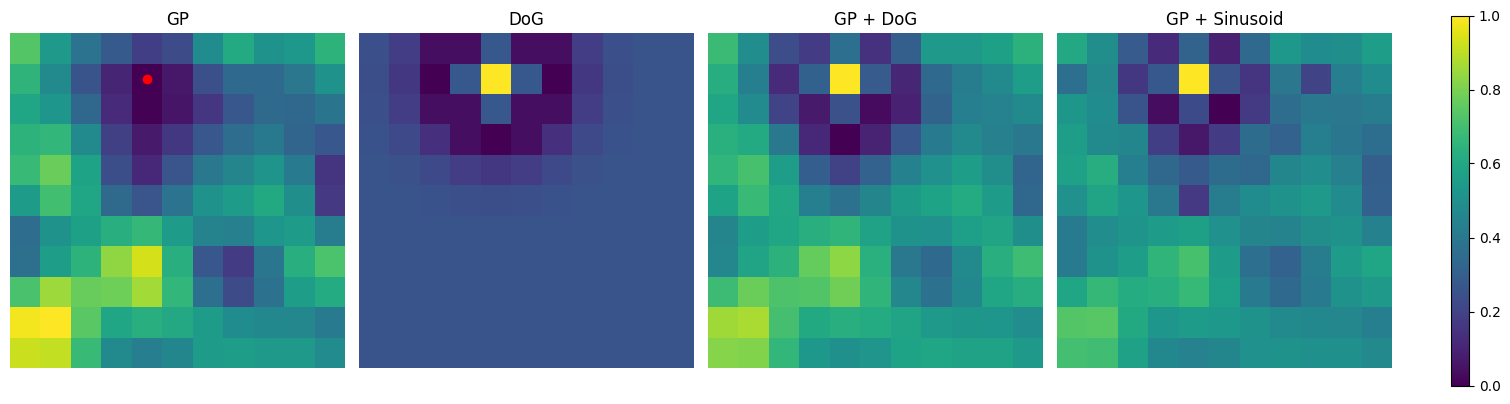

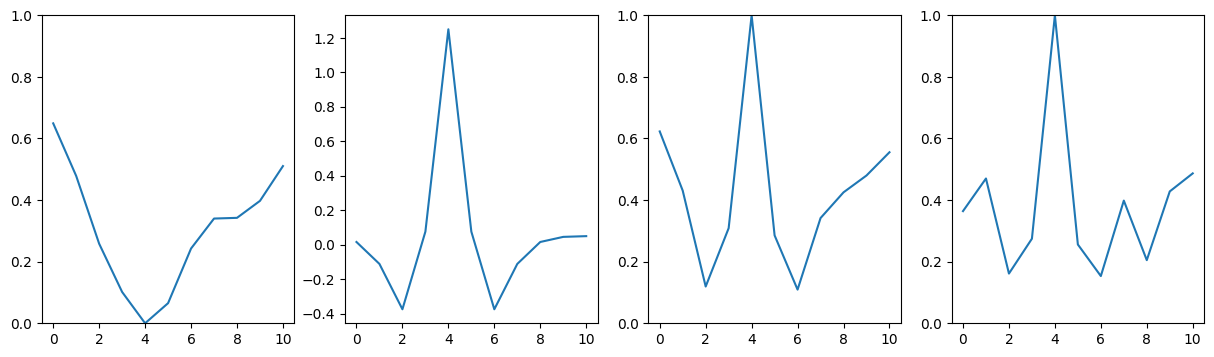

In [5]:
mix, gp, dog, (min_coords) = make_correlated_dog(
    rng, 
    grid_size=grid_size,
    length_scale=length_scale,
    sigma_outer=sigma_outer,
    sigma_inner=sigma_inner,
)
row, col = min_coords

# Generate single Gaussian at minimum of GP
sin_reward = sinusoid_landscape(grid_size=grid_size, center=min_coords, sigma_inner=sigma_inner*2, sigma_outer=sigma_outer*2)
gp_sin = _min_max(gp + sin_reward)

# Plot mixed landscape
fig, ax = plot_reward_grids(np.array([gp, dog, mix, gp_sin]), titles=['GP', 'DoG', 'GP + DoG', 'GP + Sinusoid'])
ax[0].plot(col, row, 'ro')
plt.show()

_, ax = plt.subplots(1, 4, figsize=(15, 4))
ax[0].plot(gp[row,:])
ax[1].plot(dog[row,:])
ax[2].plot(mix[row,:])
ax[3].plot(gp_sin[row,:])
ax[0].set_ylim(0, 1)
ax[2].set_ylim(0, 1)
ax[3].set_ylim(0, 1)
plt.show()

## 5. Socially correlated correlated DoGs

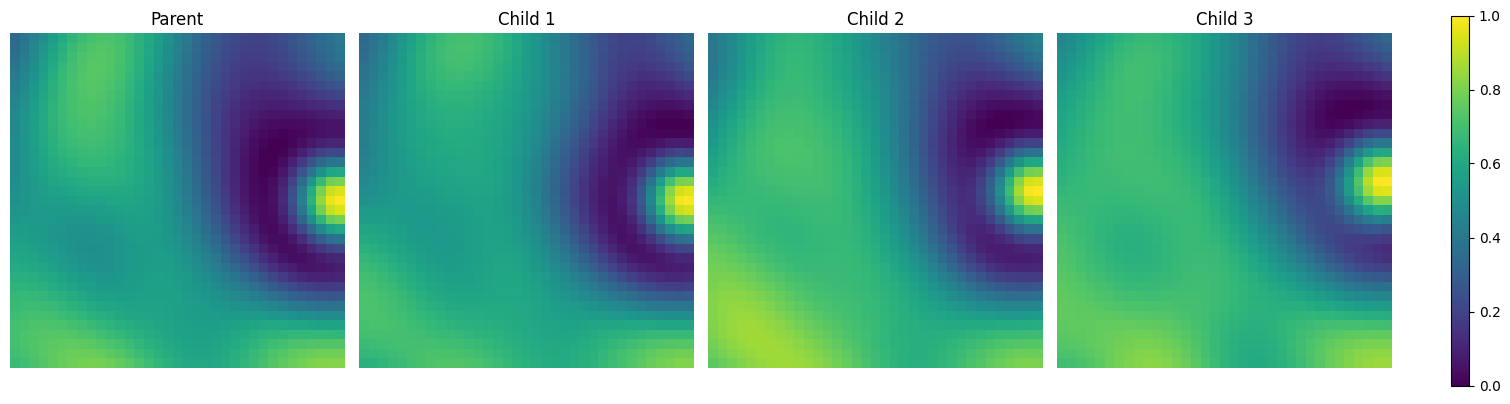

(np.False_,
 [np.float64(0.9678310604543182),
  np.float64(0.9542821861716522),
  np.float64(0.9157597393167992)])

In [261]:
rng = None # np.random.default_rng(42)
grid_size = 35
n_children = 3

parent, children, _ = make_parent_and_children_correlated_dog(
    rng, 
    grid_size=grid_size,
    n_children=n_children,
    length_scale=grid_size / 5,
    target_correlation=0.9,
)

plot_reward_grids(np.array([parent] + children), titles=['Parent'] + [f'Child {i+1}' for i in range(n_children)])
plt.show()

check_correlations(parent, children, target_correlation=0.6, tol=0.1)

## 6. Mexican hat two valleys

In [125]:
rng = np.random.default_rng(24)
grid_size = 33
length_scale= 4.5
sigma_outer= 4.5
sigma_inner= 2.25

In [136]:
mix, gp, dog, second_valley, min_coords, second_min_coords = mexican_hat_two_valleys(
    rng=rng,
    grid_size=grid_size,
    length_scale=length_scale,
    sigma_inner=sigma_inner,
    sigma_outer=sigma_outer,
    secondary_sigma=sigma_outer * 1.5,
    secondary_amplitude=0.3,
)

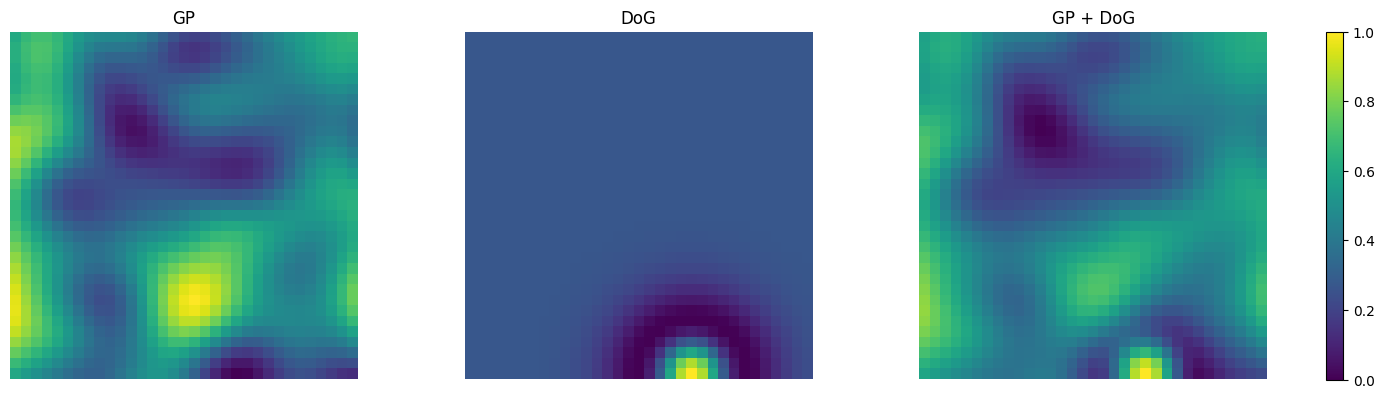

In [137]:
plot_reward_grids(np.array([gp, dog, mix]), titles=['GP', 'DoG', 'GP + DoG'])
plt.show()

# Test rewards_clean

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from abm.rewards_clean import create_mexican_hat_gp_set
from abm.rewards_utils import find_local_max
from abm.utils import plot_reward_grids

In [29]:
rng = np.random.default_rng(42)
r = 1.3
grid_size = 15
length_scale = 2.

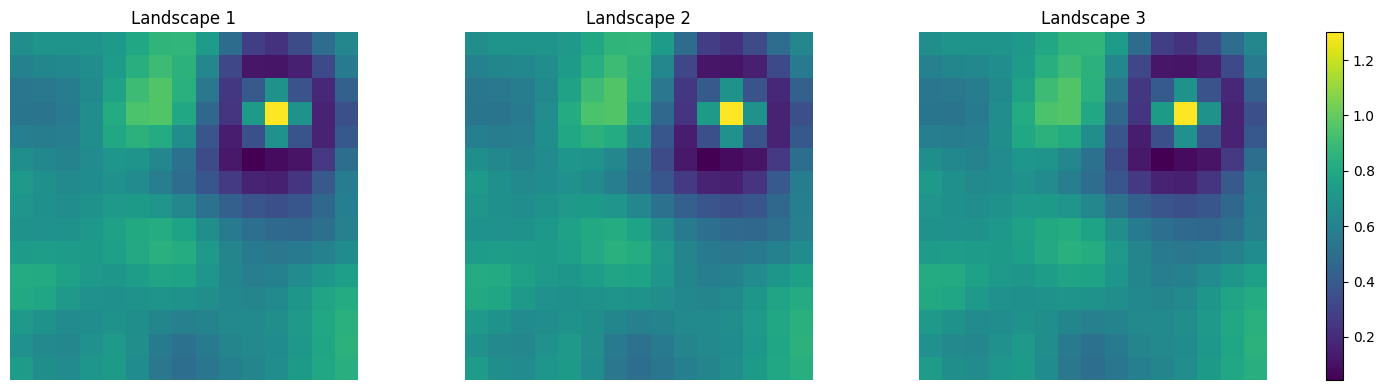

In [30]:
parent, children, g_max_coords = create_mexican_hat_gp_set(
    rng=rng,
    grid_size=grid_size,
    length_scale=length_scale,
    sigma_inner=length_scale / 2,
    sigma_outer=length_scale,
    n_children=3,
    local_global_max_ratio=r,
)

_, l_max_coords, _ = find_local_max(parent, g_max_coords, radius=length_scale * 2)

fig, axes = plot_reward_grids(np.array(children))
plt.show()

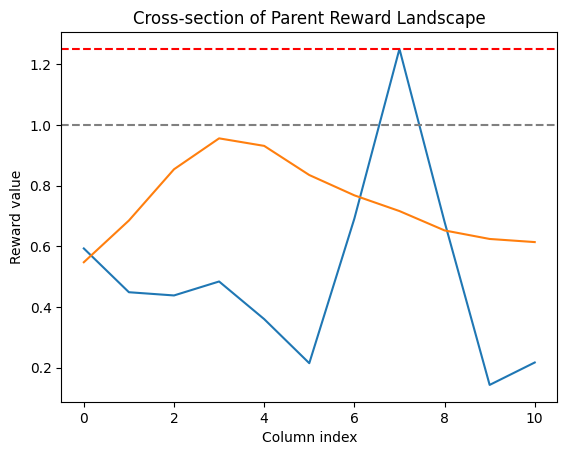

In [122]:
row_g, col_g = g_max_coords
row_l, col_l = l_max_coords
plt.plot(parent[row_g, :])
plt.plot(parent[row_l,:])
# plot horizontal lines at 1 and r
plt.axhline(1, color='gray', linestyle='--')
plt.axhline(r, color='red', linestyle='--')
plt.xlabel('Column index')
plt.ylabel('Reward value')
plt.title('Cross-section of Parent Reward Landscape')
plt.show()